In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from decimal import Decimal

In [2]:
blocks_df = pd.read_csv("../data/real_bitcoin_blocks_raw.csv")
coinbase_df = pd.read_csv("../data/coinbase_addresses_full.csv")

In [3]:
# What columns exist, and what does one row actually look like?
print("=== real_bitcoin_blocks_raw.csv ===")
print("Shape:", blocks_df.shape)
print("Columns:", list(blocks_df.columns))
print(blocks_df.head(3))

print("\n=== coinbase_addresses_full.csv ===")
print("Shape:", coinbase_df.shape)
print("Columns:", list(coinbase_df.columns))
print(coinbase_df.head(3))

=== real_bitcoin_blocks_raw.csv ===
Shape: (810909, 11)
Columns: ['number', 'timestamp', 'size', 'transaction_count', 'bits', 'block_number', 'total_output_satoshis', 'total_output_satoshis_excl_coinbase', 'total_fee_satoshis', 'tx_count_check', 'difficulty']
   number                  timestamp  size  transaction_count      bits  \
0       0  2009-01-03 18:15:05+00:00   285                  1  1d00ffff   
1       1  2009-01-09 02:54:25+00:00   215                  1  1d00ffff   
2       2  2009-01-09 02:55:44+00:00   215                  1  1d00ffff   

   block_number  total_output_satoshis  total_output_satoshis_excl_coinbase  \
0             0           5.000000e+09                                  0.0   
1             1           5.000000e+09                                  0.0   
2             2           5.000000e+09                                  0.0   

   total_fee_satoshis  tx_count_check  difficulty  
0                 0.0               1         1.0  
1                 

In [4]:
blocks_df.describe()

,number,size,transaction_count,block_number,total_output_satoshis,total_output_satoshis_excl_coinbase,total_fee_satoshis,tx_count_check,difficulty
count,810909.000000,8.109090e+05,810909.000000,810909.000000,8.109090e+05,8.109090e+05,8.109090e+05,810909.000000,8.109090e+05
mean,405454.000000,6.368584e+05,1114.224935,405454.000000,1.042921e+12,1.040482e+12,3.338222e+07,1114.224935,7.821704e+12
std,234089.409057,6.049147e+05,1123.476835,234089.409057,3.474239e+12,3.474396e+12,9.149829e+07,1123.476835,1.309043e+13
min,0.000000,1.760000e+02,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,1.000000e+00
25%,202727.000000,3.443400e+04,70.000000,202727.000000,8.612160e+10,8.352316e+10,1.990449e+06,70.000000,2.968775e+06
50%,405454.000000,4.578940e+05,682.000000,405454.000000,4.029494e+11,4.009349e+11,1.055250e+07,682.000000,1.668515e+11
75%,608181.000000,1.152505e+06,2098.000000,608181.000000,1.132216e+12,1.130369e+12,3.127132e+07,2098.000000,1.300809e+13
max,810908.000000,3.978938e+06,12239.000000,810908.000000,6.499350e+14,6.499324e+14,2.915328e+10,12239.000000,5.732151e+13


In [5]:
blocks_df["timestamp"] = pd.to_datetime(blocks_df["timestamp"])
coinbase_df["block_timestamp"] = pd.to_datetime(coinbase_df["block_timestamp"])

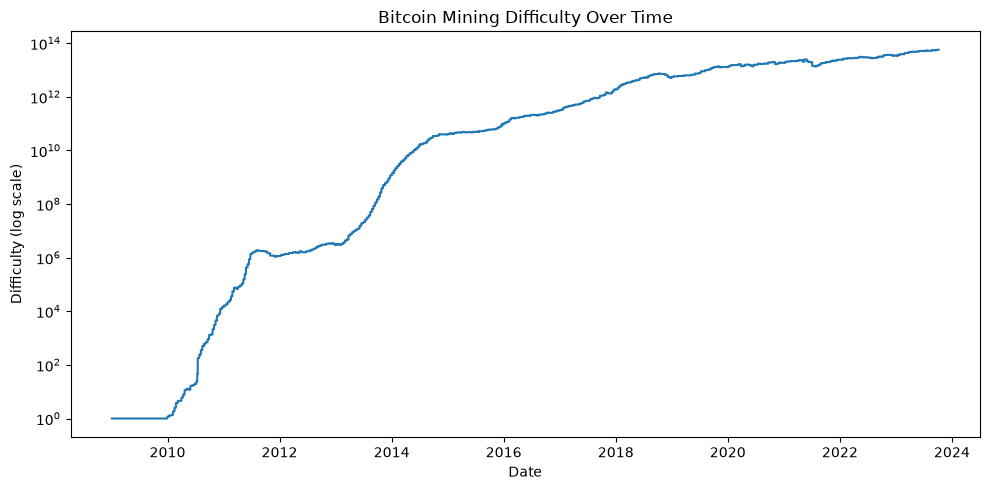

In [6]:
# --- Plot 1: Mining difficulty over time ---
# Difficulty is Bitcoin's way of measuring "how hard is it to mine a block right now."
# It grows by many orders of magnitude over 14 years, so a log scale is needed to see
# the shape at all — on a normal scale, the early years would look like a flat line at zero.
plt.figure(figsize=(10, 5))
plt.plot(blocks_df["timestamp"], blocks_df["difficulty"])
plt.yscale("log")
plt.xlabel("Date")
plt.ylabel("Difficulty (log scale)")
plt.title("Bitcoin Mining Difficulty Over Time")
plt.tight_layout()
#plt.savefig("plot_difficulty_over_time.png", dpi=150)
plt.show()

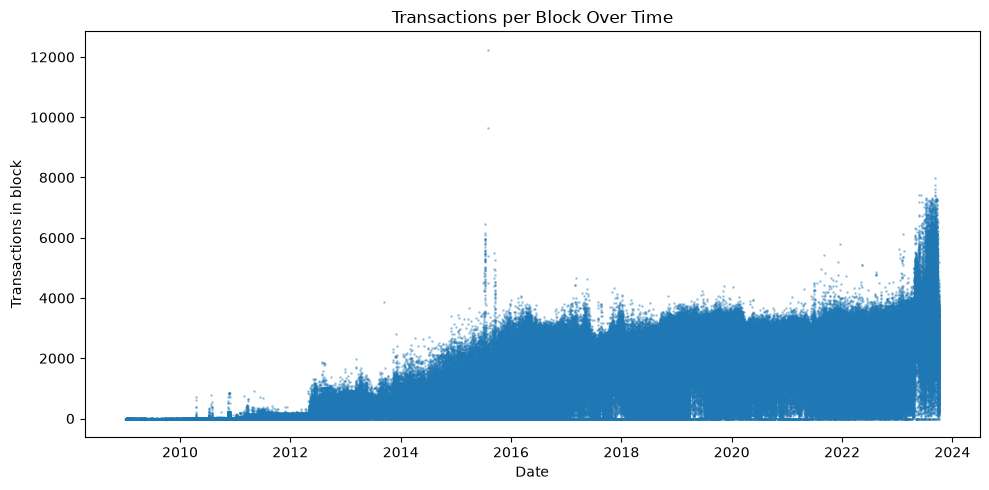

In [7]:
# --- Plot 2: Transactions per block over time ---
# Shows how blockchain usage/activity grew — early blocks often had 1 transaction
# (just the coinbase reward, nobody else using the network yet).
plt.figure(figsize=(10,5))
#plt.plot(blocks_df["timestamp"], blocks_df["transaction_count"])
plt.scatter(blocks_df["timestamp"], blocks_df["transaction_count"], s=1, alpha=0.3)
plt.xlabel("Date")
plt.ylabel("Transactions in block")
plt.title("Transactions per Block Over Time")
plt.tight_layout()
#plt.savefig("plot_transactions_over_time.png", dpi=150)
plt.show()

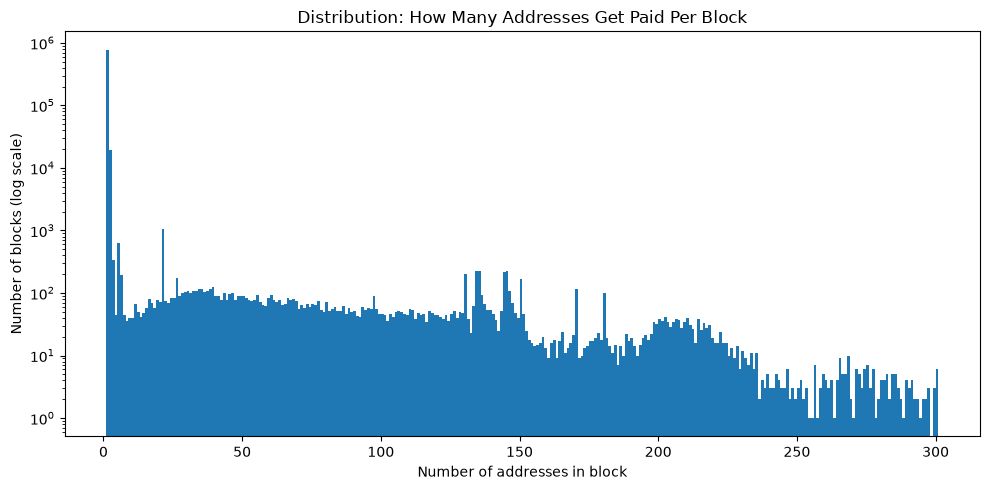

In [8]:
# --- Plot 3: How many addresses appear per block (the multi-address problem, visually) ---
# This is directly the thing we've been discussing all session — most blocks have exactly
# 1 address, a smaller number have 2, and a long tail stretches out to ~300.
def parse_outputs(s):
    fixed = re.sub(r"\}\s*\n\s*\{", "}, {", s)
    return eval(fixed, {"Decimal": Decimal, "__builtins__": {}})

coinbase_df["n_addresses"] = coinbase_df["real_outputs"].apply(lambda s: len(parse_outputs(s)))

plt.figure(figsize=(10, 5))
plt.hist(coinbase_df["n_addresses"], bins=range(1, 302), log=True)
plt.xlabel("Number of addresses in block")
plt.ylabel("Number of blocks (log scale)")
plt.title("Distribution: How Many Addresses Get Paid Per Block")
plt.tight_layout()
#plt.savefig("plot_addresses_per_block.png", dpi=150)
plt.show()

In [9]:
from collections import Counter

coinbase_df["n_addresses"] = coinbase_df["real_outputs"].apply(lambda s: len(parse_outputs(s)))

# --- Step 1: Find the exact peak in the bumpy region, rather than eyeballing it ---
counts_per_n = coinbase_df.groupby("n_addresses").size()
print("Block counts for n_addresses between 130 and 150:")
print(counts_per_n.loc[130:150])

peak_n = counts_per_n.loc[130:150].idxmax()
print(f"\nPeak found at n_addresses = {peak_n}, with {counts_per_n[peak_n]} blocks")

# --- Step 2: Pull out exactly those blocks ---
peak_blocks = coinbase_df[coinbase_df["n_addresses"] == peak_n].copy()
print(f"\nTimestamp range for these {len(peak_blocks)} blocks:")
print(peak_blocks["block_timestamp"].min(), "to", peak_blocks["block_timestamp"].max())

# Do they cluster tightly in a specific window, or spread evenly across years?
peak_blocks["year_month"] = peak_blocks["block_timestamp"].dt.to_period("M")
print("\nBlocks by year-month:")
print(peak_blocks["year_month"].value_counts().sort_index())

# --- Step 3: Do the same addresses keep reappearing across these blocks? ---
# This is the key test: if one pool consistently pays the same ~140 workers,
# we'd expect heavy overlap in *which* addresses show up, not just the *count*.
def get_address_set(s):
    outputs = parse_outputs(s)
    return frozenset(o["address"] for o in outputs)

peak_blocks["address_set"] = peak_blocks["real_outputs"].apply(get_address_set)

address_counter = Counter()
for addr_set in peak_blocks["address_set"]:
    address_counter.update(addr_set)

print(f"\nTop 10 most frequently recurring addresses across these {len(peak_blocks)} blocks:")
for addr, count in address_counter.most_common(10):
    print(f"  {addr}: appears in {count} of {len(peak_blocks)} blocks")

Block counts for n_addresses between 130 and 150:
n_addresses
130    205
131     38
132     23
133     62
134    221
135    226
136     94
137     66
138     53
139     53
140     46
141     37
142     25
143     52
144    218
145    228
146    109
147     69
148     48
149     40
150    169
dtype: int64

Peak found at n_addresses = 145, with 228 blocks

Timestamp range for these 228 blocks:
2012-02-05 12:45:28+00:00 to 2017-04-29 22:09:26+00:00

Blocks by year-month:
year_month
2012-02     1
2013-12     3
2014-01    27
2014-02    69
2014-03    37
2014-04    13
2014-05    20
2014-06    28
2014-07    12
2014-09     2
2014-11     1
2015-03     3
2015-04     2
2015-07     1
2015-10     3
2015-12     1
2016-05     1
2016-07     1
2016-10     1
2017-04     2
Freq: M, Name: count, dtype: int64


C:\Users\KwokYenMing\AppData\Local\Temp\ipykernel_16372\3824040356.py:19: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  peak_blocks["year_month"] = peak_blocks["block_timestamp"].dt.to_period("M")



Top 10 most frequently recurring addresses across these 228 blocks:
  18d3HV2bm94UyY4a9DrPfoZ17sXuiDQq2B: appears in 224 of 228 blocks
  1ChANGeATMH8dFnj39wGTjfjudUtLspzXr: appears in 224 of 228 blocks
  1Nbq2XZaRsKknf5fcT2wTXvBS31PaUWSeX: appears in 46 of 228 blocks
  1D5FhoiuLMJJ43BCMGidwvbKWfr71g1vH9: appears in 27 of 228 blocks
  1Hzo3525hh4SSncRAyhE9yBAGsquSwCcRj: appears in 25 of 228 blocks
  1QLHVd6e965XoLdWPLFQKhYKs3togqeUWc: appears in 22 of 228 blocks
  159FeYxUKekbvmBu2CyWTKAH3yHhyP3qQj: appears in 21 of 228 blocks
  1E3kbVQ8v3F5Ctd7yKJGj8nU8Ut8S4NyeS: appears in 21 of 228 blocks
  18aqApcddJhR7RSE3VsriR5zpmuStKaT5A: appears in 21 of 228 blocks
  15Po4qkyz95nMPWSbZqfKK12NvbLKKnzRp: appears in 19 of 228 blocks


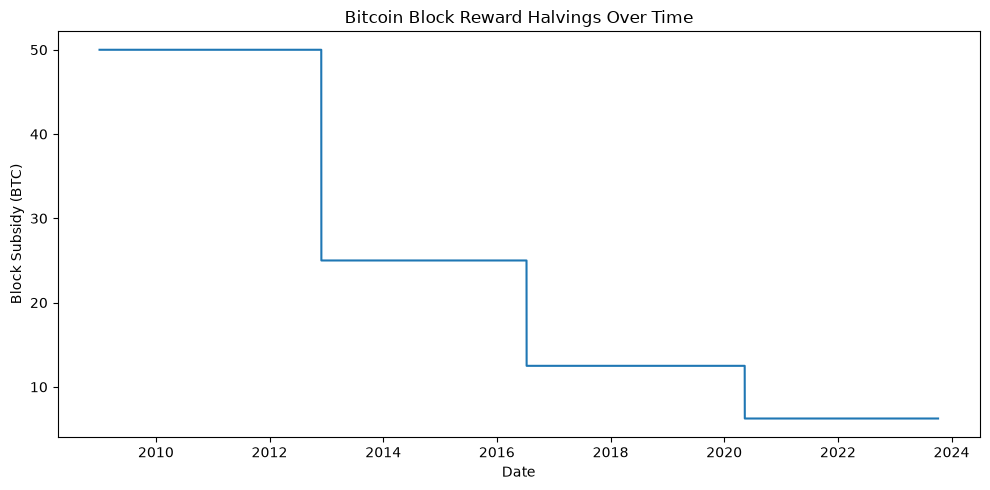

In [10]:
# --- Plot 4: Block reward (subsidy) over time — the halving step-function ---
# This should look like a literal staircase dropping every ~4 years: 50 -> 25 -> 12.5 -> 6.25 BTC.
def block_subsidy_btc(block_number):
    halvings = block_number // 210_000
    return 50 / (2 ** halvings)

blocks_df["subsidy_btc"] = blocks_df["number"].apply(block_subsidy_btc)

plt.figure(figsize=(10, 5))
plt.plot(blocks_df["timestamp"], blocks_df["subsidy_btc"])
plt.xlabel("Date")
plt.ylabel("Block Subsidy (BTC)")
plt.title("Bitcoin Block Reward Halvings Over Time")
plt.tight_layout()
#plt.savefig("plot_halvings.png", dpi=150)
plt.show()